# $\textrm{SO}(3)$ Simulation

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
from geomstats.geometry.special_orthogonal import SpecialOrthogonal
from geomstats.geometry.special_orthogonal import _SpecialOrthogonal3Vectors
import geomstats.visualization as visualization

from scipy.spatial.transform import Rotation

In [2]:
plt.rcParams.update({'font.size': 10,
                     'mathtext.fontset': 'stix',
                     'font.family': 'serif',
                     'font.serif':'Palatino'})

## Setting up

In [3]:
SO3 = SpecialOrthogonal(n=3)
tau2 = 0.1
n = 200
sigma2 = 0.3

In [4]:
# classes = np.random.randint(0,2,n).reshape(-1,1,1)
# samples1 = np.asarray([SO3.projection(np.random.normal(mean1,np.sqrt(tau2),
#                                                     size=(3,3))) for i in range(n)])
# samples2 = np.asarray([SO3.projection(np.random.normal(mean2,np.sqrt(tau2),
#                                                     size=(3,3))) for i in range(n)])
# Theta =  classes*samples1 + (1-classes)*samples2

# Theta = np.asarray([SO3.projection(np.random.normal(np.diag([1., 1., 1.]),np.sqrt(tau2),
#    size=(3,3))) for i in range(n)])

Theta = np.zeros((n,3,3))
for i in range(n):
    u = np.random.uniform(0,1)
    theta = (2*np.pi*u)
    R = np.asarray([[1., 0., 0.,],
                    [0., np.cos(theta), np.sin(-theta)],
                    [0., np.sin(theta), np.cos(theta)]])
    A = np.random.normal(0,np.sqrt(tau2),size=(3,3))
    Theta[i,:,:] = SO3.projection(SO3.metric.exp(Theta[i,:,:] + 0.5*(A-A.T), R))
    
X = np.zeros((n,3,3))
for i in range(n):
    A = np.random.normal(0,np.sqrt(sigma2),size=(3,3))
    X[i,:,:] = SO3.projection(SO3.metric.exp(0.5*(A-A.T), Theta[i,:,:]))
    
Theta_angs = _SpecialOrthogonal3Vectors().tait_bryan_angles_from_matrix(Theta, extrinsic=True, zyx=True)
X_angs = _SpecialOrthogonal3Vectors().tait_bryan_angles_from_matrix(X, extrinsic=True, zyx=True)

Text(0.5, 0.98, 'Riemannian Gaussian in SO$(3)$ (Tait-Bryan Euler angles)')

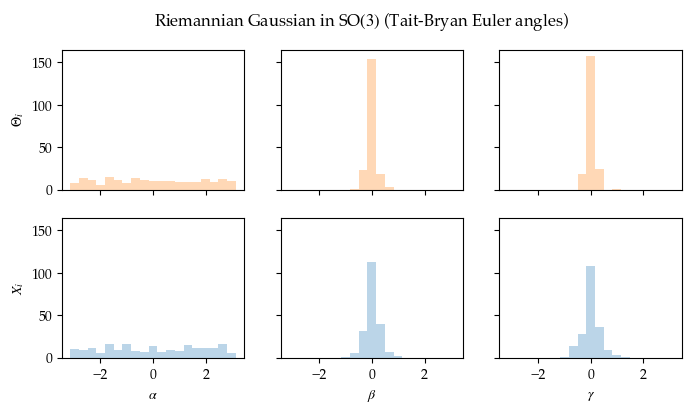

In [5]:
fig, axs = plt.subplots(2, 3, figsize=(8,4), sharex=True,sharey=True)

bins = np.linspace(-np.pi, np.pi, num=20)

for m in range(3):
    axs[0,m].hist(Theta_angs[:,m], bins=bins, color='C1', alpha=0.3)
    axs[1,m].hist(X_angs[:,m], bins=bins, color='C0', alpha=0.3)
    
axs[1,0].set_xlabel('$\\alpha$')
axs[1,1].set_xlabel('$\\beta$')
axs[1,2].set_xlabel('$\\gamma$')

axs[0,0].set_ylabel('$\\Theta_i$')
axs[1,0].set_ylabel('$X_i$')


plt.suptitle('Riemannian Gaussian in SO$(3)$ (Tait-Bryan Euler angles)')

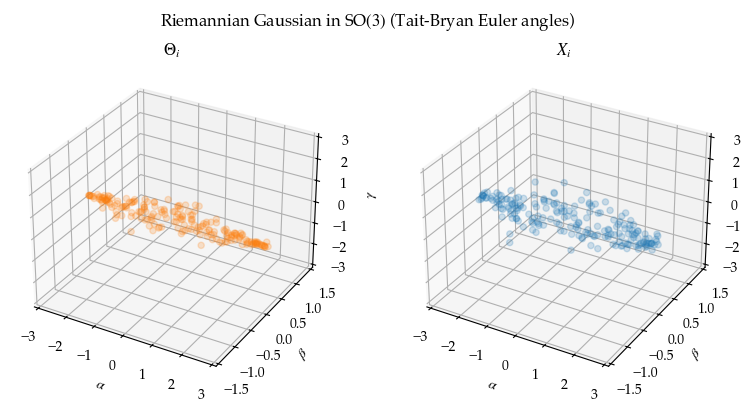

In [6]:
fig = plt.figure(figsize=(8,4))
ax = [None] * 2

ax[0] = fig.add_subplot(1, 2, 1, projection='3d')

ax[0].scatter(Theta_angs[:,0], Theta_angs[:,1], Theta_angs[:,2], color='C1', alpha=0.2)
ax[0].set_title('$\\Theta_i$')

ax[1] = fig.add_subplot(1, 2, 2, projection='3d')

ax[1].scatter(X_angs[:,0], X_angs[:,1], X_angs[:,2], color='C0', alpha=0.2)
ax[1].set_title('$X_i$')

for m in range(2):
    ax[m].set_xlabel('$\\alpha$')
    ax[m].set_ylabel('$\\beta$')
    ax[m].set_zlabel('$\\gamma$')

    ax[m].set_xlim([-np.pi, np.pi])
    ax[m].set_ylim([-np.pi/2, np.pi/2])
    ax[m].set_zlim([-np.pi, np.pi])

plt.suptitle('Riemannian Gaussian in SO$(3)$ (Tait-Bryan Euler angles)')
plt.tight_layout()

## Empirical Bayes denoising

In [7]:
def denoiser(X_, M, rho):
    
    pairwise_dists = dists = SO3.metric.dist_pairwise(X)
    print(pairwise_dists.shape)
    
    # estimate f
    print('density and score estimation...', end='')
    hat_f = np.zeros(shape=X_.shape[0])
    hat_grad_f = np.zeros(shape=(X_.shape[0],3,3))
    for i in range(X.shape[0]):
        for m in range(M):
            p_m = sp.special.chebyu(2*m, monic=False)
            p_m_deriv = sp.special.chebyu(2*m).deriv()
            hat_f += (2*m+1)*p_m(np.real(np.cos(pairwise_dists[i,:]/2)))/X.shape[0]      
            hat_grad_f += (2*m+1)*np.outer(np.real(p_m_deriv(np.cos(pairwise_dists[i,:]/2))), X[i,:,:]).reshape(X.shape[0],3,3)/X.shape[0]
    print(' done.')
    
    if np.isnan(hat_f).any() or np.isnan(hat_grad_f).any():
        print('nan in score')

    
    # compute score function
    hat_score = hat_grad_f / np.maximum(hat_f, rho).reshape(-1,1,1)
    
    # compute denoiser
    print('computing denoiser...', end='')
    delta = np.zeros((X_.shape[0],3,3))
    for j in range(X_.shape[0]):
        deltaj = SO3.projection(SO3.metric.exp(X_[j,:,:] + sigma2*hat_score[j,:,:], X_[j,:,:]))
        if np.isnan(deltaj).any():
            delta[j,:,:] = X[j,:,:]
        else:
            delta[j,:,:] = deltaj
    print(' done.')
    
        
    return delta

In [8]:
M = 2
rho = 0.01
delta = denoiser(X, M, rho)
delta_angs = _SpecialOrthogonal3Vectors().tait_bryan_angles_from_matrix(delta, extrinsic=True, zyx=True)

(200, 200)
density and score estimation... done.
computing denoiser... done.


## Plotting

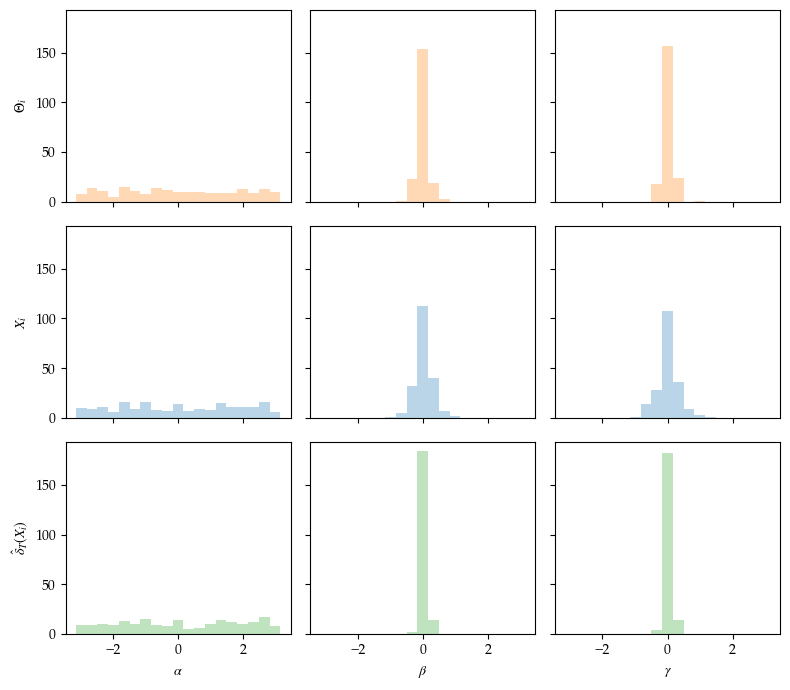

In [9]:
fig, axs = plt.subplots(3, 3, figsize=(8,7), sharex=True,sharey=True)

bins = np.linspace(-np.pi, np.pi, num=20)

for m in range(3):
    axs[0,m].hist(Theta_angs[:,m], bins=bins, color='C1', alpha=0.3)
    axs[1,m].hist(X_angs[:,m], bins=bins, color='C0', alpha=0.3)
    axs[2,m].hist(delta_angs[:,m], bins=bins, color='C2', alpha=0.3)
    
axs[2,0].set_xlabel('$\\alpha$')
axs[2,1].set_xlabel('$\\beta$')
axs[2,2].set_xlabel('$\\gamma$')

axs[0,0].set_ylabel('$\\Theta_i$')
axs[1,0].set_ylabel('$X_i$')
axs[2,0].set_ylabel('$\\hat{\delta}_T(X_i)$')

plt.tight_layout()
plt.savefig('cryoEM_marginals.pdf')

/var/folders/4l/9wthfjb520bf_3mctz_1csd00000gn/T/ipykernel_7571/3344331740.py:44: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


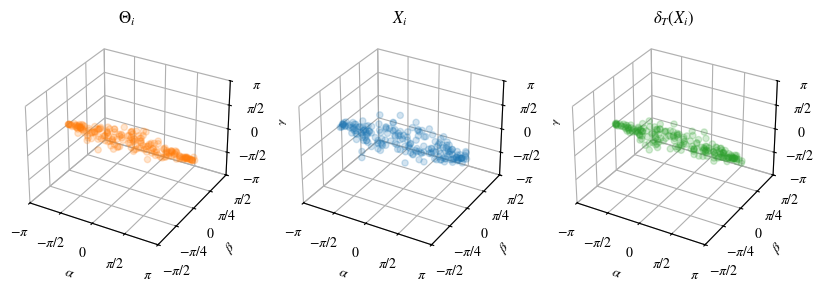

In [10]:
fig = plt.figure(figsize=(10,4))
ax = [None] * 3

ax[0] = fig.add_subplot(1, 3, 1, projection='3d')
ax[0].scatter(Theta_angs[:,0], Theta_angs[:,1], Theta_angs[:,2], color='C1', alpha=0.2)
ax[0].set_title('$\\Theta_i$')

ax[1] = fig.add_subplot(1, 3, 2, projection='3d')
ax[1].scatter(X_angs[:,0], X_angs[:,1], X_angs[:,2], color='C0', alpha=0.2)
ax[1].set_title('$X_i$')

ax[2] = fig.add_subplot(1, 3, 3, projection='3d')
ax[2].scatter(delta_angs[:,0], delta_angs[:,1], X_angs[:,2], color='C2', alpha=0.2)
ax[2].set_title('$\\delta_{T}(X_i)$')


radian_xzticks = [i * np.pi/4 for i in range(-4,5,2)]
radian_xzticklabels = ['$-\\pi$', '$-\\pi/2$', '$0$', '$\\pi/2$', '$\\pi$']

radian_yticks = [i * np.pi/8 for i in range(-4,5,2)]
radian_yticklabels = ['$-\\pi/2$', '$-\\pi/4$', '$0$', '$\\pi/4$', '$\\pi/2$']

for m in range(3):
    ax[m].set_xlabel('$\\alpha$')
    ax[m].set_ylabel('$\\beta$')
    ax[m].set_zlabel('$\\gamma$')

    ax[m].set_xlim([-np.pi, np.pi])
    ax[m].set_ylim([-np.pi/2, np.pi/2])
    ax[m].set_zlim([-np.pi, np.pi])
    
    ax[m].set_xticks(radian_xzticks)
    ax[m].set_yticks(radian_yticks)
    ax[m].set_zticks(radian_xzticks)

    ax[m].set_xticklabels(radian_xzticklabels)
    ax[m].set_yticklabels(radian_yticklabels)
    ax[m].set_zticklabels(radian_xzticklabels)
    
    ax[m].xaxis.pane.fill = False
    ax[m].yaxis.pane.fill = False
    ax[m].zaxis.pane.fill = False

plt.tight_layout()
plt.savefig('cryoEM.pdf')

In [11]:
print('MSE of delta_N:', np.mean(SO3.metric.squared_dist(X,Theta)))
print('MSE of delta_T:', np.mean(SO3.metric.squared_dist(delta,Theta)))

MSE of delta_N: 0.20076150727312458
MSE of delta_T: 0.12051196243549551


In [12]:
mse_n = np.mean(SO3.metric.squared_dist(X,Theta))
mse_t = np.mean(SO3.metric.squared_dist(delta,Theta))

In [13]:
(mse_n-mse_t)/mse_n

0.39972575384410786